In [1]:
# from google.colab import drive
# drive.mount('/content/drive')


To use ANN for the Iris Classification using the **sklearn** deep learning framework.

In [2]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split

# header = None : means no header line in the front.
# Each column is given a name.

# data_raw = pd.read_csv('/content/drive/MyDrive/ELEC6604_Sept2022/Class4_folder/iris_dataset.csv', header = None, sep = ',')

data_raw = pd.read_csv('iris_dataset.csv', header = None, sep = ',')
data_raw.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']


print('shape of data_raw is ',data_raw.shape)

shape of data_raw is  (150, 5)


# CASE 1: Use one output ;  i.e. target output is 0,1 or 2

In [4]:
# CASE 1: Use one output ;  i.e. target output is 0,1 or 2

df1_X = data_raw[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

# The following line would map the names to an integer label:
df1_y = data_raw['class'].map({'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2})

# We load in 150 samples and the following line using “train_test_split” would split it
# into 120 training data and 30 testing data (20% is for testing)
X1_train, X1_test, y1_train, y1_test = train_test_split(df1_X, df1_y, test_size = 0.2)

print(X1_train.shape)
# (120,4)
print(X1_test.shape)
# (30,4)

df1_y


(120, 4)
(30, 4)


0      0
1      0
2      0
3      0
4      0
5      0
6      0
7      0
8      0
9      0
10     0
11     0
12     0
13     0
14     0
15     0
16     0
17     0
18     0
19     0
20     0
21     0
22     0
23     0
24     0
25     0
26     0
27     0
28     0
29     0
      ..
120    2
121    2
122    2
123    2
124    2
125    2
126    2
127    2
128    2
129    2
130    2
131    2
132    2
133    2
134    2
135    2
136    2
137    2
138    2
139    2
140    2
141    2
142    2
143    2
144    2
145    2
146    2
147    2
148    2
149    2
Name: class, Length: 150, dtype: int64

In [5]:
# The model is defined with two hidden layers of ten nodes below:
rgs1 = MLPRegressor(solver = 'lbfgs', alpha = 1e-10, hidden_layer_sizes = (10,10), random_state = 1, max_iter = 1000)

rgs1.fit(X1_train.values, y1_train.values)

# MLPRegressor(activation='relu', alpha=1e-10, batch_size='auto', beta_1=0.9,
#       beta_2=0.999, early_stopping=False, epsilon=1e-08,
#       hidden_layer_sizes=(10, 10), learning_rate='constant',
#       learning_rate_init=0.001, max_iter=1000, momentum=0.9,
#       nesterovs_momentum=True, power_t=0.5, random_state=1, shuffle=True,
#       solver='lbfgs', tol=0.0001, validation_fraction=0.1, verbose=False,
#       warm_start=False)
"""
solver{‘lbfgs’, ‘sgd’, ‘adam’}, default=’adam’
The solver for weight optimization.
•	‘lbfgs’ is an optimizer in the family of quasi-Newton methods.
•	‘sgd’ refers to stochastic gradient descent.
•	‘adam’ refers to a stochastic gradient-based optimizer.
Note: The default solver ‘adam’ works pretty well on relatively large datasets
(with thousands of training samples or more) in terms of both training time and
validation score. For small datasets, however, ‘lbfgs’ can converge faster and perform better.
Notice that this ANN has ONE output.  """

y1_ANN = rgs1.predict(X1_test)
print(y1_ANN.shape)
# (30,)
print(len(y1_ANN))
# 30
print('ANN output values (thirty of them): ')
print(y1_ANN)
print('ANN output values (after rounding): ')
y1_round = np.round(y1_ANN)
print(y1_round)
print('Desired output values (thirty of them): ')
print(y1_test.values)



(30,)
30
ANN output values (thirty of them): 
[ 0.97266988  0.99704477  0.9755527   1.99156252 -0.0183633   1.98289772
 -0.02601203  1.00539778  1.03117056  0.96516208 -0.00424006  0.99640354
  1.9971348   1.0100857  -0.05465018  1.01528568 -0.04801749 -0.01375962
 -0.00747473 -0.00668703  0.02508002  1.01869137  0.97238071  0.01477276
  1.01294441 -0.01952075  1.98437114  1.98949351 -0.02814682  1.9898915 ]
ANN output values (after rounding): 
[ 1.  1.  1.  2. -0.  2. -0.  1.  1.  1. -0.  1.  2.  1. -0.  1. -0. -0.
 -0. -0.  0.  1.  1.  0.  1. -0.  2.  2. -0.  2.]
Desired output values (thirty of them): 
[1 1 1 2 0 2 0 1 1 2 0 1 2 1 0 1 0 0 0 0 0 1 2 0 1 0 2 2 0 2]


**Note that simple rounding of the ANN output values are used !**

In [6]:
print('Differences between the ANN and Desired outputs: ')
print(np.abs(y1_round - y1_test.values))
print('Number of output cases: ')
print(len(y1_round))

print('Next is to calculate the accuracy in percentage: ')
acc1 = (1 - np.round(sum(np.abs(y1_round - y1_test.values)/len(y1_round)),4))*100
print('The Accuracy is:', acc1, '%')

Differences between the ANN and Desired outputs: 
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0.]
Number of output cases: 
30
Next is to calculate the accuracy in percentage: 
The Accuracy is: 93.33 %


# CASE 2: Use three outputs




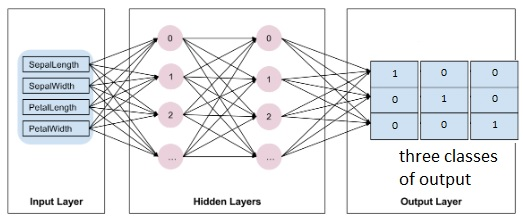

In the example of CASE 2, we define three outputs for the ANN.
Note that rounding is also used for the three ANN outputs.

In [10]:
# CASE 2: Use three outputs

# The following creates three more columns, and use three digits to represent each class
df2 = data_raw.copy()
df2['class1'] = df2['class'].map({'Iris-setosa':1})
df2['class2'] = df2['class'].map({'Iris-versicolor':1})
df2['class3'] = df2['class'].map({'Iris-virginica':1})
df2 = df2.fillna(0)

print('df2 = ',df2)

df2_X = df2[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
df2_y = df2[['class1', 'class2','class3']]

X2_train, X2_test, y2_train, y2_test = train_test_split(df2_X, df2_y, test_size = 0.2)

rgs2 = MLPRegressor(solver = 'lbfgs', alpha = 1e-10, hidden_layer_sizes = (10,10), random_state = 1, max_iter = 1000)

rgs2.fit(X2_train.values, y2_train.values)


y2_ANN = rgs2.predict(X2_test)

y2_ANN_round = np.round(y2_ANN)
# Note that a simple "round off" is used to find the nearest match to the output class.

error_output = (y2_ANN_round - y2_test).values

print('*** error_output is ',error_output)
# Number of test cases
len(error_output)

df2 =       sepal_length  sepal_width  petal_length  petal_width           class  \
0             5.1          3.5           1.4          0.2     Iris-setosa   
1             4.9          3.0           1.4          0.2     Iris-setosa   
2             4.7          3.2           1.3          0.2     Iris-setosa   
3             4.6          3.1           1.5          0.2     Iris-setosa   
4             5.0          3.6           1.4          0.2     Iris-setosa   
5             5.4          3.9           1.7          0.4     Iris-setosa   
6             4.6          3.4           1.4          0.3     Iris-setosa   
7             5.0          3.4           1.5          0.2     Iris-setosa   
8             4.4          2.9           1.4          0.2     Iris-setosa   
9             4.9          3.1           1.5          0.1     Iris-setosa   
10            5.4          3.7           1.5          0.2     Iris-setosa   
11            4.8          3.4           1.6          0.2     Iris-se

30

In [11]:
for i in range(0,len(error_output)):
    if (error_output[i][0] != 0  or error_output[i][1] != 0 or error_output[i][2] != 0 ):
        print('Case ',i,' is a mistake !')

Case  17  is a mistake !
